# Suspicious Identification Flagging System

**Goal:** Combine multiple independent signals to flag compound identifications that
warrant expert review, and identify "green" confirmations that boost confidence.

**Red flags** (suspicious signals):

| Flag | Signal | What it catches |
|---|---|---|
| `SIM_GAP_SMALL` | top ref sim − 2nd ref sim < 0.05 | MS2 can't distinguish candidates |
| `LOW_ID_HIGH_FUZZY` | identity < 0.3 & fuzzy > 0.7 | Open search matches but precursor-constrained doesn't → ISF signal |
| `RT_FAR` | \|delta_predicted_RT\| > 40s | RT prediction way off |
| `LOW_ENTROPY` | query spectrum entropy < 0.5 | Uninformative spectrum (1-2 peaks) |
| `POTENTIAL_ISF` | RT within 3s of a higher-mass spectrum | In-source fragment candidate |
| `NO_ALTERNATIVE` | only 1 reference hit (2nd sim = 0) | Forced call, no competition |

**Green flags** (confidence boosters):

| Flag | Signal | What it means |
|---|---|---|
| `MULTI_ADDUCT` | compound seen with 2+ adducts at same RT | Independent corroboration from multiple ionization forms |

**Data:** Oliver's Orbitrap HILIC negESI spreadsheet (2026-03-19), 5,971 spectra.

**Output:** `results/current/flagged_review_queue.csv` — sorted by flag count.

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

ROOT = '/Users/ellayoung/Desktop/metabolo_confi_score'
OUT  = f'{ROOT}/results/current'
HITS_FILE = f'{ROOT}/data/library_hits/orbitrap_hilic_neg_masswiki_hits.csv'

# ── Load Oliver's Orbitrap spreadsheet ──────────────────────────────────────
raw = pd.read_excel(
    f'{ROOT}/data/masswiki_Orbitrap HILIC negESI_2026-03-19.xlsx',
    sheet_name='masswiki_result_2026-03-19',
    header=4
)

# Clean column names for easier access
df = raw.rename(columns={
    'identity_score':                           'identity',
    'fuzzy_score':                              'fuzzy',
    'identity_score_reference_library_':         'ref_sim_1st',
    'reference_library_search-identity_score_2nd': 'ref_sim_2nd',
    'reference_library_search-identity_score_3rd': 'ref_sim_3rd',
    'reference_library_search-fuzzy_score':      'ref_fuzzy',
    'reference_library_search-name':             'ref_name_1st',
    'reference_library_search-name_2nd':         'ref_name_2nd',
    'annotation_library_search-identity_score':  'anno_sim',
    'annotation_library_search-fuzzy_score':     'anno_fuzzy',
    'oliver\'s ad hoc probability':              'oliver_prob',
    'DRTpred':                                   'delta_rt_pred',
    'Unnamed: 36':                               'oliver_comment',
})

# Ensure numeric
for col in ['ref_sim_1st', 'ref_sim_2nd', 'ref_sim_3rd', 'delta_rt_pred', 'entropy',
            'identity', 'fuzzy', 'ref_fuzzy', 'anno_sim', 'anno_fuzzy', 'oliver_prob']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Filter out ISTDs (rows starting with '1_')
is_istd = df['name'].astype(str).str.startswith('1_')
print(f'Total rows: {len(df)}')
print(f'ISTDs removed: {is_istd.sum()}')
df = df[~is_istd].copy()
print(f'Working set: {len(df)} spectra')

# ── Load full MassWiki hits (fetched by fetch_orbitrap_hits.py) ────────────
import os
if os.path.exists(HITS_FILE):
    hits = pd.read_csv(HITS_FILE, low_memory=False)
    hits['entropy_similarity'] = pd.to_numeric(hits['entropy_similarity'], errors='coerce')
    print(f'\nMassWiki hits loaded: {len(hits)} rows, {hits["wiki_id"].nunique()} spectra')
    HAS_FULL_HITS = True
else:
    print(f'\nWARNING: {HITS_FILE} not found — run code/fetch_orbitrap_hits.py first')
    print('Falling back to spreadsheet top-3 for sim gap (less accurate)')
    HAS_FULL_HITS = False

Total rows: 5971
ISTDs removed: 4
Working set: 5967 spectra

MassWiki hits loaded: 267645 rows, 4476 spectra


## Define flags

In [ ]:
# ── Red Flag 1: SIM_GAP_SMALL ─────────────────────────────────────────────
# Gap between the best hit and the best DIFFERENT compound.
# Deduplicate by InChIKey14 (first 14 chars of InChIKey from SMILES) to
# avoid false alarms from synonyms (28.2% of "different name" pairs share
# the same InChIKey14).

if HAS_FULL_HITS:
    from rdkit import Chem
    from rdkit.Chem.inchi import MolFromInchi, InchiToInchiKey, MolToInchi

    def smiles_to_inchikey14(smi):
        """Convert SMILES → first 14 chars of InChIKey (connectivity layer)."""
        if not isinstance(smi, str) or not smi.strip():
            return None
        try:
            mol = Chem.MolFromSmiles(smi)
            if mol is None:
                return None
            ik = InchiToInchiKey(MolToInchi(mol))
            return ik[:14] if ik else None
        except Exception:
            return None

    ref_hits = hits[hits['hit_source'] == 'reference'].copy()

    # Compute InChIKey14 for each hit from SMILES
    unique_smiles = ref_hits['smiles'].dropna().unique()
    smi_to_ik14 = {smi: smiles_to_inchikey14(smi) for smi in unique_smiles}
    ref_hits['ik14'] = ref_hits['smiles'].map(smi_to_ik14)

    # For hits without SMILES, fall back to lib_name as the dedup key
    ref_hits['dedup_key'] = ref_hits['ik14'].fillna(ref_hits['lib_name'])

    # Deduplicate: for each (wiki_id, dedup_key), keep the best sim
    best_per_compound = (ref_hits
        .sort_values('entropy_similarity', ascending=False)
        .groupby(['wiki_id', 'dedup_key'])
        .first()
        .reset_index()
    )

    # For each spectrum, get top 2 DISTINCT compounds by sim
    ranked = (best_per_compound
        .sort_values(['wiki_id', 'entropy_similarity'], ascending=[True, False])
        .groupby('wiki_id')
    )
    top1_full = ranked.nth(0).set_index('wiki_id')[['entropy_similarity', 'lib_name', 'dedup_key']].rename(
        columns={'entropy_similarity': 'hit_sim_1st', 'lib_name': 'hit_name_1st', 'dedup_key': 'hit_key_1st'})
    top2_full = ranked.nth(1).set_index('wiki_id')[['entropy_similarity', 'lib_name', 'dedup_key']].rename(
        columns={'entropy_similarity': 'hit_sim_2nd', 'lib_name': 'hit_name_2nd', 'dedup_key': 'hit_key_2nd'})

    sim_gap_df = top1_full.join(top2_full)
    sim_gap_df['real_sim_gap'] = sim_gap_df['hit_sim_1st'] - sim_gap_df['hit_sim_2nd']

    # Count distinct compounds per spectrum (by InChIKey14)
    n_compounds = best_per_compound.groupby('wiki_id')['dedup_key'].nunique().rename('n_distinct_compounds')
    sim_gap_df = sim_gap_df.join(n_compounds)

    # Total hits per spectrum
    n_total_hits = ref_hits.groupby('wiki_id').size().rename('n_total_hits')
    sim_gap_df = sim_gap_df.join(n_total_hits)

    # How many had SMILES → InChIKey14?
    n_with_ik14 = ref_hits['ik14'].notna().sum()
    n_total = len(ref_hits)
    print(f'InChIKey14 coverage: {n_with_ik14}/{n_total} hits ({n_with_ik14/n_total*100:.1f}%)')

    df = df.merge(sim_gap_df[['real_sim_gap', 'hit_name_1st', 'hit_name_2nd',
                               'hit_key_1st', 'hit_key_2nd',
                               'n_distinct_compounds', 'n_total_hits']],
                  left_on='wiki_id', right_index=True, how='left')

    df['ref_sim_gap'] = df['real_sim_gap']
    print(f'Full-hit sim gap (InChIKey14 dedup): {df["ref_sim_gap"].notna().sum()} spectra with computable gap')
    print(f'  mean gap: {df["ref_sim_gap"].mean():.3f}')
    print(f'  median gap: {df["ref_sim_gap"].median():.3f}')
    print(f'Distinct compounds per spectrum: mean={df["n_distinct_compounds"].mean():.1f}')
    print(f'Total hits per spectrum: mean={df["n_total_hits"].mean():.1f}')
else:
    # Fallback: use spreadsheet top-3 (noisy — 66.5% of 1st==2nd)
    df['ref_sim_gap'] = df['ref_sim_1st'] - df['ref_sim_2nd']
    df['n_distinct_compounds'] = np.nan
    df['n_total_hits'] = np.nan

df['FLAG_SIM_GAP_SMALL'] = (df['ref_sim_gap'] < 0.05) & (df['ref_sim_gap'].notna())

# ── Red Flag 2: LOW_ID_HIGH_FUZZY ─────────────────────────────────────────
# Precursor-constrained search (identity) < 0.3 but open search (fuzzy) > 0.7
# → fragment pattern matches openly but not with correct precursor mass
# Primary interpretation: in-source fragmentation (ISF)
df['FLAG_LOW_ID_HIGH_FUZZY'] = (df['identity'] < 0.3) & (df['fuzzy'] > 0.7)

# ── Red Flag 3: RT_FAR ────────────────────────────────────────────────────
# |delta predicted RT| > 40s
df['FLAG_RT_FAR'] = df['delta_rt_pred'].abs() > 40

# ── Red Flag 4: LOW_ENTROPY ───────────────────────────────────────────────
# Query spectrum entropy < 0.5 → too few informative peaks
df['FLAG_LOW_ENTROPY'] = df['entropy'] < 0.5

# ── Red Flag 5: POTENTIAL_ISF ─────────────────────────────────────────────
# In-source fragment with NEUTRAL LOSS FILTER (FIXED):
# Flag only if a co-eluting higher-mass spectrum exists AND the Δm/z matches
# a known neutral loss from literature. This fixes the 99.4% false positive rate.

# Comprehensive neutral loss table for negative-mode ESI
# Sources: Kind & Fiehn (2007), McLafferty & Tureček, METLIN, MassBank
NEUTRAL_LOSSES = {
    'H2O': 18.0106,          # water: alcohols, carboxylic acids, sugars
    'NH3': 17.0265,          # ammonia: amines, amides
    'CO': 27.9949,           # carbon monoxide: aldehydes, ketones
    'CO2': 43.9898,          # carbon dioxide: carboxylic acids, esters
    'formic_acid': 46.0055,  # formic acid: formate adducts
    'H2SO3': 81.9883,        # sulfurous acid
    'SO3': 79.9568,          # sulfur trioxide: sulfates
    'H3PO4': 97.9769,        # phosphoric acid: phosphorylated compounds
    'hexose': 162.0528,      # hexose (C6H10O5): glycosylated compounds
    'H2O_CO2': 61.9898,      # combined loss: water + CO2
    '2xH2O': 36.0211,        # double water: diols, polyols, sugars
    'CH3OH': 32.0262,        # methanol: methoxy groups
    'C2H4O2': 60.0211,       # acetic acid or ethylene glycol
    'C3H6O': 58.0419,        # acetone or related ketones
    'C3H8O': 60.0575,        # propanol: propoxy groups
    'H2SO4': 97.9877,        # sulfuric acid: sulfate esters
}

LOSS_TOLERANCE = 0.01  # Da (suitable for Orbitrap/QTOF accuracy)

# Find co-eluting spectra with mass differences matching known losses
rt_vals = df[['wiki_id', 'rt', 'precursor_mz']].dropna().copy()
rt_vals = rt_vals.sort_values('rt').reset_index(drop=True)

isf_suspects = {}  # wiki_id → (parent_wiki_id, loss_name, delta_mz)
rts = rt_vals['rt'].values
mzs = rt_vals['precursor_mz'].values
wids = rt_vals['wiki_id'].values

# For each spectrum, check co-eluting spectra within ±3s RT window
for i in range(len(rts)):
    for j in range(i + 1, min(i + 50, len(rts))):  # limit search window for efficiency
        if rts[j] - rts[i] > 3.0:
            break  # no more co-elutions
        
        # Check if one is lower-mass and matches a known loss
        if mzs[i] < mzs[j]:
            delta_mz = mzs[j] - mzs[i]
            for loss_name, loss_mass in NEUTRAL_LOSSES.items():
                if abs(delta_mz - loss_mass) < LOSS_TOLERANCE:
                    wid_lower = wids[i]
                    wid_higher = wids[j]
                    if wid_lower not in isf_suspects:
                        isf_suspects[wid_lower] = (wid_higher, loss_name, delta_mz)
                    break
        
        elif mzs[j] < mzs[i]:
            delta_mz = mzs[i] - mzs[j]
            for loss_name, loss_mass in NEUTRAL_LOSSES.items():
                if abs(delta_mz - loss_mass) < LOSS_TOLERANCE:
                    wid_lower = wids[j]
                    wid_higher = wids[i]
                    if wid_lower not in isf_suspects:
                        isf_suspects[wid_lower] = (wid_higher, loss_name, delta_mz)
                    break

# Create diagnostic columns to track ISF evidence
df['isf_loss_type'] = np.nan
df['isf_parent_wid'] = np.nan
df['isf_delta_mz'] = np.nan

for wid, (parent_wid, loss_name, delta_mz) in isf_suspects.items():
    mask = df['wiki_id'] == wid
    df.loc[mask, 'isf_loss_type'] = loss_name
    df.loc[mask, 'isf_parent_wid'] = parent_wid
    df.loc[mask, 'isf_delta_mz'] = delta_mz

df['FLAG_POTENTIAL_ISF'] = df['wiki_id'].isin(isf_suspects)

print(f'\n=== POTENTIAL_ISF (neutral loss filter) ===')
print(f'Flagged: {df["FLAG_POTENTIAL_ISF"].sum()} ({df["FLAG_POTENTIAL_ISF"].mean()*100:.2f}%)')
print(f'Expected: ~1-5% (was 99.4% with naive co-elution)')
if df['FLAG_POTENTIAL_ISF'].sum() > 0:
    print(f'Loss types detected:')
    for loss_type in sorted(df['isf_loss_type'].dropna().unique()):
        count = (df['isf_loss_type'] == loss_type).sum()
        print(f'  {loss_type:<15s}: {count}')

# ── Red Flag 6: NO_ALTERNATIVE ────────────────────────────────────────────
# Only 1 distinct compound in the hit list (or no hits at all)
if HAS_FULL_HITS:
    df['FLAG_NO_ALTERNATIVE'] = df['n_distinct_compounds'].fillna(0) <= 1
else:
    df['FLAG_NO_ALTERNATIVE'] = df['ref_sim_2nd'] < 0.01

# ── Green Flag: MULTI_ADDUCT ──────────────────────────────────────────────
# Compound seen with 2+ adduct forms → independent corroboration
# This is a confidence BOOSTER, not a red flag.
adduct_counts = df.groupby('name')['adduct'].nunique().rename('n_adducts')
df = df.merge(adduct_counts, on='name', how='left')
df['GREEN_MULTI_ADDUCT'] = df['n_adducts'] >= 2

# ── Collect flags ─────────────────────────────────────────────────────────
red_flag_cols = [c for c in df.columns if c.startswith('FLAG_')]
green_flag_cols = [c for c in df.columns if c.startswith('GREEN_')]
df['n_red_flags'] = df[red_flag_cols].sum(axis=1)
df['n_green_flags'] = df[green_flag_cols].sum(axis=1)

print('\n=== Red flag prevalence (suspicious) ===')
for fc in red_flag_cols:
    n = df[fc].sum()
    print(f'  {fc:<30s}  {n:>5}  ({n/len(df)*100:>5.1f}%)')

print(f'\n=== Green flag prevalence (confidence boosters) ===')
for fc in green_flag_cols:
    n = df[fc].sum()
    print(f'  {fc:<30s}  {n:>5}  ({n/len(df)*100:>5.1f}%)')

print(f'\n  {"Total spectra":<30s}  {len(df):>5}')
print()
print('Red flag count distribution:')
print(df['n_red_flags'].value_counts().sort_index())
print()
print('Green + Red cross-tab:')
print(pd.crosstab(df['n_red_flags'], df['GREEN_MULTI_ADDUCT'],
                  rownames=['red_flags'], colnames=['multi_adduct']))

## Validate flags against Oliver's comments

Oliver manually commented on 124 rows. Do our flags light up on the same cases he found suspicious?

In [3]:
commented = df[df['oliver_comment'].notna()].copy()
uncommented = df[df['oliver_comment'].isna()].copy()

print(f'Commented rows: {len(commented)}   Uncommented: {len(uncommented)}')
print()

print('=== Red flag rate: commented vs uncommented ===')
print(f'{"Flag":<30s}  {"Commented":>10s}  {"Uncommented":>12s}  {"Ratio":>6s}')
print('-' * 65)
for fc in red_flag_cols:
    r_c = commented[fc].mean()
    r_u = uncommented[fc].mean()
    ratio = r_c / r_u if r_u > 0 else float('inf')
    print(f'  {fc:<28s}  {r_c:>10.1%}  {r_u:>12.1%}  {ratio:>6.1f}x')

print(f'\n=== Green flag rate: commented vs uncommented ===')
for fc in green_flag_cols:
    r_c = commented[fc].mean()
    r_u = uncommented[fc].mean()
    ratio = r_c / r_u if r_u > 0 else float('inf')
    print(f'  {fc:<28s}  {r_c:>10.1%}  {r_u:>12.1%}  {ratio:>6.1f}x')

print(f'\n  {"avg n_red_flags":<28s}  {commented["n_red_flags"].mean():>10.2f}  {uncommented["n_red_flags"].mean():>12.2f}')
print()

# Show the most-flagged commented rows
print('=== Most-flagged rows that Oliver also commented on ===')
top_flagged = commented.sort_values('n_red_flags', ascending=False).head(15)
for _, row in top_flagged.iterrows():
    red = [fc.replace('FLAG_','') for fc in red_flag_cols if row[fc]]
    green = ['MULTI_ADDUCT'] if row['GREEN_MULTI_ADDUCT'] else []
    flag_str = ' | '.join(red)
    if green:
        flag_str += f'  +GREEN: {", ".join(green)}'
    print(f'  {row["name"]:<45s} red={row["n_red_flags"]}  [{flag_str}]')
    print(f'    comment: {row["oliver_comment"]}')
    print(f'    prob={row["oliver_prob"]:.3f}  sim={row["ref_sim_1st"]:.3f}  entropy={row["entropy"]:.2f}  adducts={row["n_adducts"]:.0f}')
    print()

Commented rows: 124   Uncommented: 5843

=== Red flag rate: commented vs uncommented ===
Flag                             Commented   Uncommented   Ratio
-----------------------------------------------------------------
  FLAG_SIM_GAP_SMALL                 26.6%         29.8%     0.9x
  FLAG_LOW_ID_HIGH_FUZZY              3.2%         27.2%     0.1x
  FLAG_RT_FAR                        22.6%          2.4%     9.2x
  FLAG_LOW_ENTROPY                   12.1%          9.4%     1.3x
  FLAG_POTENTIAL_ISF                100.0%         99.4%     1.0x
  FLAG_NO_ALTERNATIVE                13.7%         34.5%     0.4x

=== Green flag rate: commented vs uncommented ===
  GREEN_MULTI_ADDUCT                 15.3%          5.8%     2.6x

  avg n_red_flags                     1.78          2.03

=== Most-flagged rows that Oliver also commented on ===
  methanolphosphate                             red=4  [RT_FAR | LOW_ENTROPY | POTENTIAL_ISF | NO_ALTERNATIVE]
    comment: no alternative hit. One low 

## Visualize flag distributions

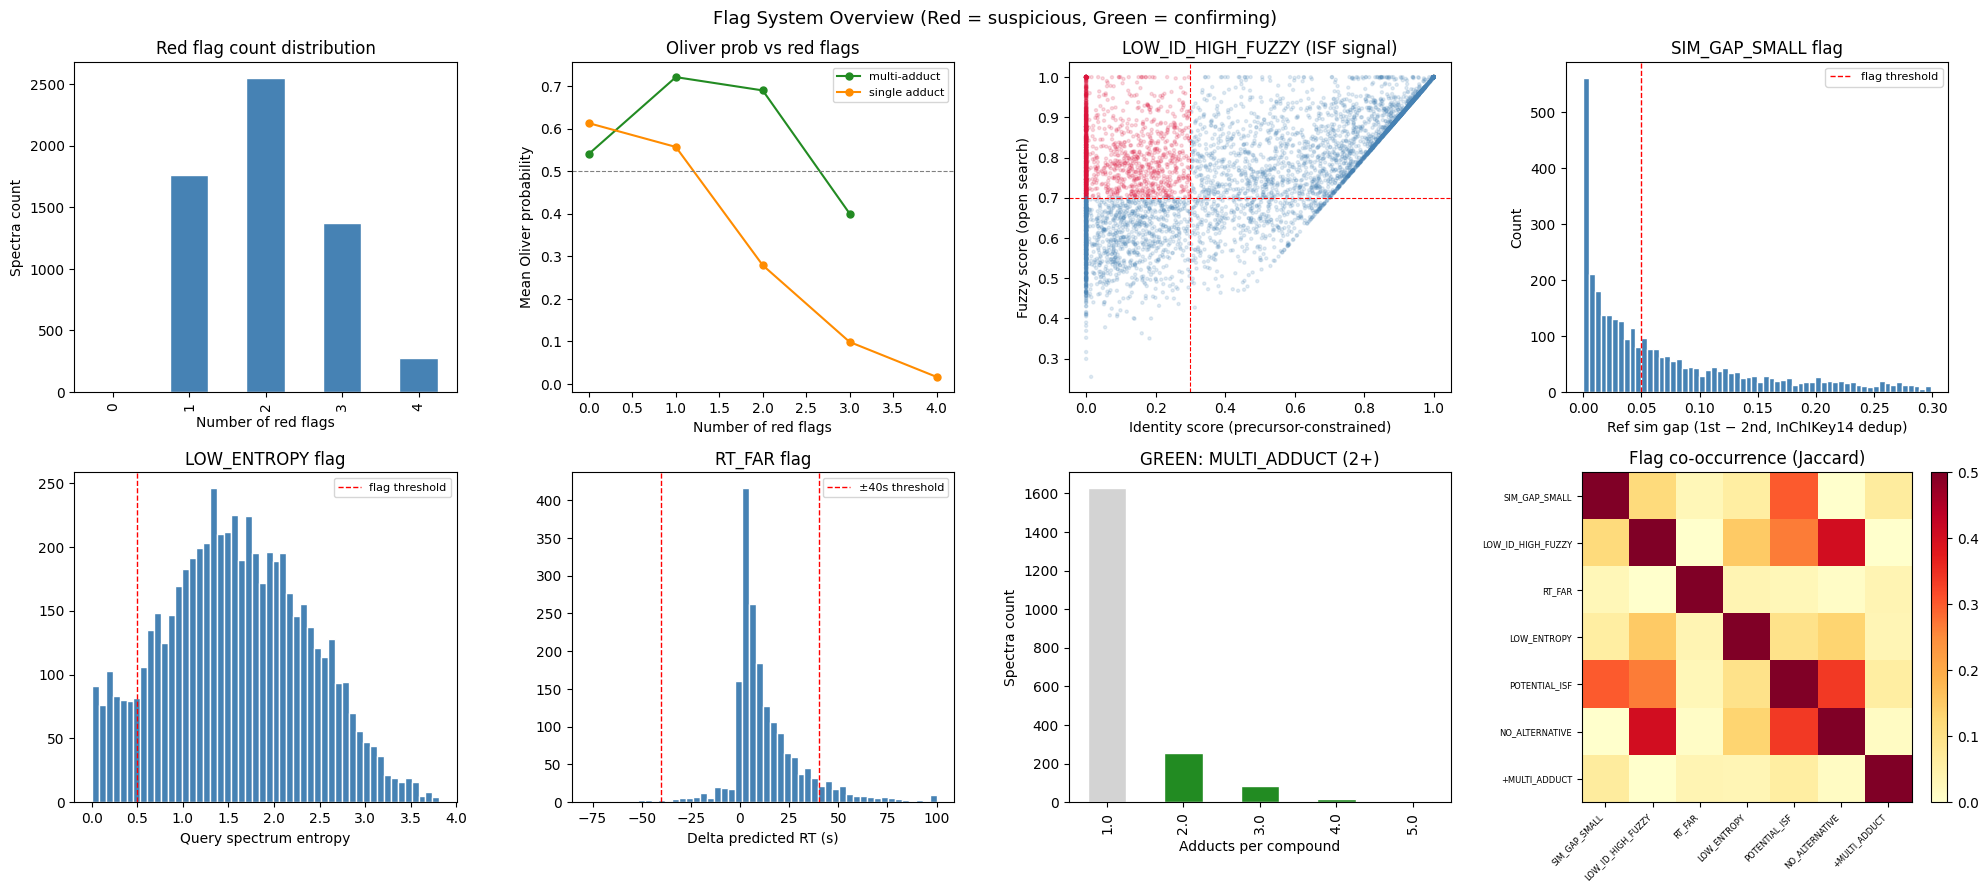

In [4]:
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
fig.suptitle('Flag System Overview (Red = suspicious, Green = confirming)', fontsize=13)

# ── Panel 1: red flag count histogram ─────────────────────────────────────
ax = axes[0, 0]
df['n_red_flags'].value_counts().sort_index().plot.bar(ax=ax, color='steelblue', edgecolor='white')
ax.set_xlabel('Number of red flags')
ax.set_ylabel('Spectra count')
ax.set_title('Red flag count distribution')

# ── Panel 2: Oliver prob vs n_red_flags, split by multi-adduct ────────────
ax = axes[0, 1]
for is_green, color, label in [(True, 'forestgreen', 'multi-adduct'), (False, 'darkorange', 'single adduct')]:
    sub = df[(df['oliver_prob'].notna()) & (df['GREEN_MULTI_ADDUCT'] == is_green)]
    means = sub.groupby('n_red_flags')['oliver_prob'].mean()
    ax.plot(means.index, means.values, 'o-', color=color, label=label, markersize=5)
ax.set_xlabel('Number of red flags')
ax.set_ylabel('Mean Oliver probability')
ax.set_title('Oliver prob vs red flags')
ax.axhline(0.5, color='gray', ls='--', lw=0.8)
ax.legend(fontsize=8)

# ── Panel 3: identity vs fuzzy, colored by flag ───────────────────────────
ax = axes[0, 2]
colors = np.where(df['FLAG_LOW_ID_HIGH_FUZZY'], 'crimson', 'steelblue')
ax.scatter(df['identity'], df['fuzzy'], c=colors, alpha=0.15, s=5)
ax.set_xlabel('Identity score (precursor-constrained)')
ax.set_ylabel('Fuzzy score (open search)')
ax.set_title('LOW_ID_HIGH_FUZZY (ISF signal)')
ax.axvline(0.3, color='red', ls='--', lw=0.8)
ax.axhline(0.7, color='red', ls='--', lw=0.8)

# ── Panel 4: sim gap distribution ─────────────────────────────────────────
ax = axes[0, 3]
gap = df['ref_sim_gap'].dropna()
ax.hist(gap[gap < 0.3], bins=60, color='steelblue', edgecolor='white')
ax.axvline(0.05, color='red', ls='--', lw=1, label='flag threshold')
ax.set_xlabel('Ref sim gap (1st − 2nd, InChIKey14 dedup)')
ax.set_ylabel('Count')
ax.set_title('SIM_GAP_SMALL flag')
ax.legend(fontsize=8)

# ── Panel 5: entropy distribution ─────────────────────────────────────────
ax = axes[1, 0]
ax.hist(df['entropy'], bins=50, color='steelblue', edgecolor='white')
ax.axvline(0.5, color='red', ls='--', lw=1, label='flag threshold')
ax.set_xlabel('Query spectrum entropy')
ax.set_title('LOW_ENTROPY flag')
ax.legend(fontsize=8)

# ── Panel 6: delta RT pred distribution ───────────────────────────────────
ax = axes[1, 1]
drt = df['delta_rt_pred'].dropna()
ax.hist(drt.clip(-100, 100), bins=50, color='steelblue', edgecolor='white')
ax.axvline(40, color='red', ls='--', lw=1)
ax.axvline(-40, color='red', ls='--', lw=1, label='±40s threshold')
ax.set_xlabel('Delta predicted RT (s)')
ax.set_title('RT_FAR flag')
ax.legend(fontsize=8)

# ── Panel 7: adduct count — green flag ────────────────────────────────────
ax = axes[1, 2]
vc = df['n_adducts'].value_counts().sort_index().head(6)
bar_colors = ['forestgreen' if x >= 2 else 'lightgray' for x in vc.index]
vc.plot.bar(ax=ax, color=bar_colors, edgecolor='white')
ax.set_xlabel('Adducts per compound')
ax.set_ylabel('Spectra count')
ax.set_title('GREEN: MULTI_ADDUCT (2+)')

# ── Panel 8: flag co-occurrence heatmap ───────────────────────────────────
ax = axes[1, 3]
all_flag_cols = red_flag_cols + green_flag_cols
flag_matrix = df[all_flag_cols].astype(int)
co_occur = flag_matrix.T @ flag_matrix
diag = np.diag(co_occur.values)
jaccard = co_occur.values / (diag[:, None] + diag[None, :] - co_occur.values + 1e-6)
np.fill_diagonal(jaccard, 1)
short_names = [c.replace('FLAG_', '').replace('GREEN_', '+') for c in all_flag_cols]
im = ax.imshow(jaccard, cmap='YlOrRd', vmin=0, vmax=0.5)
ax.set_xticks(range(len(short_names)))
ax.set_xticklabels(short_names, rotation=45, ha='right', fontsize=6)
ax.set_yticks(range(len(short_names)))
ax.set_yticklabels(short_names, fontsize=6)
ax.set_title('Flag co-occurrence (Jaccard)')
plt.colorbar(im, ax=ax, fraction=0.046)

plt.tight_layout()
plt.savefig(f'{ROOT}/figures/flag_system_overview.png', dpi=150, bbox_inches='tight')
plt.show()

## Annotated vs unannotated: flag profile comparison

If flags are capturing real quality signals, unannotated spectra should have more flags
than manually confirmed ones.

Annotated: 1984   Unannotated: 3983

Flag                             Annotated   Unannotated
-------------------------------------------------------
  FLAG_SIM_GAP_SMALL                 33.0%         28.2%
  FLAG_LOW_ID_HIGH_FUZZY              0.4%         39.8%
  FLAG_RT_FAR                         8.6%          0.0%
  FLAG_LOW_ENTROPY                   10.4%          8.9%
  FLAG_POTENTIAL_ISF                 99.4%         99.4%
  FLAG_NO_ALTERNATIVE                 7.6%         47.3%
  GREEN_MULTI_ADDUCT                 18.0%          0.0%

  avg n_red_flags                     1.59          2.24


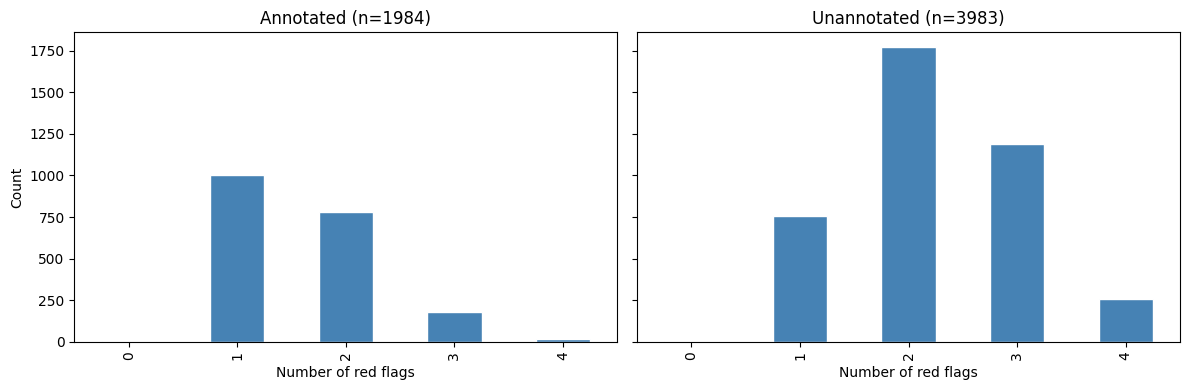

In [5]:
is_annotated = df['annotation-name'].notna()
anno = df[is_annotated]
unanno = df[~is_annotated]

print(f'Annotated: {len(anno)}   Unannotated: {len(unanno)}')
print()
print(f'{"Flag":<30s}  {"Annotated":>10s}  {"Unannotated":>12s}')
print('-' * 55)
for fc in red_flag_cols:
    print(f'  {fc:<28s}  {anno[fc].mean():>10.1%}  {unanno[fc].mean():>12.1%}')
for fc in green_flag_cols:
    print(f'  {fc:<28s}  {anno[fc].mean():>10.1%}  {unanno[fc].mean():>12.1%}')
print(f'\n  {"avg n_red_flags":<28s}  {anno["n_red_flags"].mean():>10.2f}  {unanno["n_red_flags"].mean():>12.2f}')

# Flag count histograms side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, sub, title in [(axes[0], anno, 'Annotated'), (axes[1], unanno, 'Unannotated')]:
    sub['n_red_flags'].value_counts().sort_index().plot.bar(ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(f'{title} (n={len(sub)})')
    ax.set_xlabel('Number of red flags')
    ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig(f'{ROOT}/figures/flag_anno_vs_unanno.png', dpi=150, bbox_inches='tight')
plt.show()

## Export review queue

Sort all spectra by flag count (descending), then by Oliver's probability (ascending).
The top of the list = most suspicious, review first.

In [6]:
export_cols = [
    'wiki_id', 'name', 'adduct', 'precursor_mz', 'rt',
    'identity', 'fuzzy', 'entropy',
    'ref_sim_1st', 'ref_sim_2nd', 'ref_sim_gap',
    'ref_name_1st', 'ref_name_2nd',
    'delta_rt_pred', 'n_adducts',
    'oliver_prob', 'oliver_comment',
    'annotation-name', 'annotation-adduct',
]

# Add full-hits columns if available
if HAS_FULL_HITS:
    for c in ['hit_name_1st', 'hit_name_2nd', 'hit_key_1st', 'hit_key_2nd',
              'n_distinct_compounds', 'n_total_hits']:
        if c in df.columns:
            export_cols.append(c)

export_cols += red_flag_cols + green_flag_cols + ['n_red_flags', 'n_green_flags']

queue = df[export_cols].sort_values(
    ['n_red_flags', 'oliver_prob'],
    ascending=[False, True]
).copy()

queue.to_csv(f'{OUT}/flagged_review_queue.csv', index=False)
print(f'Saved {len(queue)} rows → {OUT}/flagged_review_queue.csv')
print()

# Show the top 20 most suspicious
print('=== Top 20 most suspicious identifications ===')
for i, (_, row) in enumerate(queue.head(20).iterrows()):
    red = [fc.replace('FLAG_', '') for fc in red_flag_cols if row[fc]]
    green = [fc.replace('GREEN_', '+') for fc in green_flag_cols if row[fc]]
    flag_str = ' | '.join(red)
    if green:
        flag_str += f'  [{", ".join(green)}]'
    comment = f'  // {row["oliver_comment"]}' if pd.notna(row['oliver_comment']) else ''
    prob_str = f'prob={row["oliver_prob"]:+.3f}' if pd.notna(row['oliver_prob']) else 'prob=N/A'
    print(f'{i+1:>3}. {row["name"]:<40s} red={row["n_red_flags"]}  {prob_str}')
    gap_str = f'gap={row["ref_sim_gap"]:.3f}' if pd.notna(row['ref_sim_gap']) else 'gap=N/A'
    drt_str = f'ΔRT={row["delta_rt_pred"]:.0f}s' if pd.notna(row['delta_rt_pred']) else 'ΔRT=N/A'
    print(f'     sim={row["ref_sim_1st"]:.3f}  {gap_str}  '
          f'entropy={row["entropy"]:.2f}  {drt_str}  adducts={row["n_adducts"]:.0f}{comment}')
    print(f'     [{flag_str}]')
    print()

Saved 5967 rows → /Users/ellayoung/Desktop/metabolo_confi_score/results/current/flagged_review_queue.csv

=== Top 20 most suspicious identifications ===
  1. yy_tetradecane-7-sulfonic acid too late  red=4  prob=-1.067
     sim=1.000  gap=0.001  entropy=0.17  ΔRT=133s  adducts=1
     [SIM_GAP_SMALL | RT_FAR | LOW_ENTROPY | POTENTIAL_ISF]

  2. yy_epoxytricarballylic acid              red=4  prob=-0.497
     sim=0.778  gap=0.017  entropy=0.15  ΔRT=104s  adducts=1
     [SIM_GAP_SMALL | RT_FAR | LOW_ENTROPY | POTENTIAL_ISF]

  3. yy_tetradecane-7-sulfonic acid too late  red=4  prob=-0.400
     sim=1.000  gap=0.001  entropy=0.17  ΔRT=87s  adducts=1
     [SIM_GAP_SMALL | RT_FAR | LOW_ENTROPY | POTENTIAL_ISF]

  4. yy_maleic acid                           red=4  prob=-0.357
     sim=0.706  gap=0.000  entropy=0.45  ΔRT=92s  adducts=1
     [SIM_GAP_SMALL | RT_FAR | LOW_ENTROPY | POTENTIAL_ISF]

  5. yy_phosphate                             red=4  prob=-0.240
     sim=0.911  gap=N/A  entropy=0.4

ValueError: Unknown format code 's' for object of type 'float'

## Summary statistics

In [ ]:
print('=== Flag System Summary ===')
print(f'Total spectra scored: {len(df)}')
print(f'\nRed flags (suspicious):')
print(f'  0 red flags (clean): {(df["n_red_flags"] == 0).sum()} ({(df["n_red_flags"] == 0).mean()*100:.1f}%)')
print(f'  1 red flag:          {(df["n_red_flags"] == 1).sum()} ({(df["n_red_flags"] == 1).mean()*100:.1f}%)')
print(f'  2 red flags:         {(df["n_red_flags"] == 2).sum()} ({(df["n_red_flags"] == 2).mean()*100:.1f}%)')
print(f'  3+ red flags:        {(df["n_red_flags"] >= 3).sum()} ({(df["n_red_flags"] >= 3).mean()*100:.1f}%)')
print(f'\nGreen flags (confidence boosters):')
print(f'  MULTI_ADDUCT:        {df["GREEN_MULTI_ADDUCT"].sum()} ({df["GREEN_MULTI_ADDUCT"].mean()*100:.1f}%)')
print()
print('Mean Oliver probability by red flag count:')
for nf in sorted(df['n_red_flags'].unique()):
    sub = df[df['n_red_flags'] == nf]
    prob = sub['oliver_prob'].mean()
    n_green = sub['GREEN_MULTI_ADDUCT'].mean()
    print(f'  {nf} red flags: prob={prob:.3f}  multi_adduct={n_green:.1%}  (n={len(sub)})')
print()
print('Mean Oliver probability by multi-adduct status:')
for ma in [True, False]:
    sub = df[(df['GREEN_MULTI_ADDUCT'] == ma) & df['oliver_prob'].notna()]
    label = 'multi-adduct' if ma else 'single adduct'
    print(f'  {label}: prob={sub["oliver_prob"].mean():.3f}  (n={len(sub)})')